<a href="https://colab.research.google.com/github/VelasquezE/FourierOptics_assignments/blob/main/talleres/Taller02/taller02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Importar librerías necesarias

In [926]:
import numpy as np
import cv2
import seaborn as sns
import os
import cmath

from scipy.fft import fft2
from scipy.fft import fftshift
from scipy import signal

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from matplotlib.animation import PillowWriter
from google.colab.patches import cv2_imshow
import matplotlib.patches as patches

from typing import Callable, Tuple

In [927]:
# Estilo por defecto para notebooks
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

# Personalización gráficas

sns.set_style("darkgrid")

custom_rc = {
    "xtick.bottom": True,
    "ytick.left": True,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.edgecolor": "black",
    "grid.color": "#bbbbbb",
    "grid.linestyle": "dashed",
    "axes.grid": True,
    "axes.spines.top": True,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True
}
sns.set_context("notebook")
sns.set_style("darkgrid", rc = custom_rc)

Se crea una carpeta para los resultados parciales,

In [928]:
folder_name = "register"
os.makedirs(folder_name, exist_ok = "True")

# 0.1. Se definen las constantes

In [929]:
N = 512 # Window size
F = 50 # mm
LAMBDA = 6.32e-4 # mm
k = 2 * np.pi / LAMBDA
Z_O = -75 # mm
DELTA_X = 0.01 # mm

Y, se crea una función que calcule la posición de la imagen,

In [930]:
def get_image_position(f: int, z_o: float) -> float:
  x_o = z_o + f
  x_i = - (f ** 2) / x_o
  z_i = x_i + f

  return z_i

z_i = get_image_position(F, Z_O)

print(f"La posición de la imagen es: {z_i:0.1f} mm")

La posición de la imagen es: 150.0 mm


# 1. Simulación del objeto (letra E)

Se genera la ventana de $N \times N$ píxeles, con $N = 512$.

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

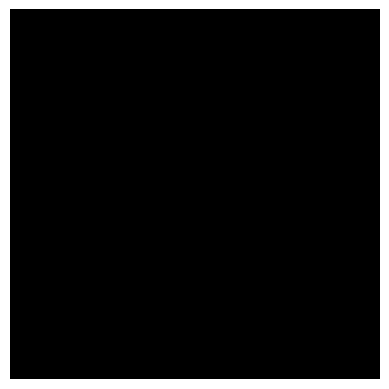

In [931]:
window = np.zeros((N, N))

plt.imshow(window, cmap = "gray")
plt.axis("off")

El píxel tendrá un tamaño de $10\mu m$. Entonces, la pantalla tiene un tamaño de $5,12 mm$. Guiándose de la imagen proporcionada, se fija una altura para la E de 100 píxeles, con 50 de ancho, y 20 de espesor para los rectángulos que componen la letra.

In [932]:
H_E = 100 # Height
W_E = 50 # Width
D_E = 20 # Depth

window_xcenter = N // 2
window_ycenter = N // 2

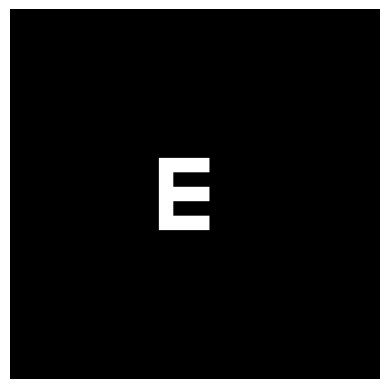

In [933]:
start_x = window_xcenter - (H_E // 2)
start_y = window_ycenter - (H_E // 2)

letter_e = window.copy()

letter_e[start_y:(start_y + H_E), start_x:(start_x + D_E)] = 1

start_x = start_x + D_E

for ii in np.arange(0, 6, 2):
  letter_e[(start_y + (ii * D_E)):(start_y + (ii + 1) * D_E), start_x:(start_x + W_E)] = 1

plt.imshow(letter_e, cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/letter_E.png", dpi=300, bbox_inches='tight')

Esta E será $I_{0}(x,y) = I_{g}(\frac{u}{M}, \frac{v}{M})$.

# 2. Construir la función pupila $P_{s}(x,y)$

Dado que $PSF = |\mathcal{F} \{h(u,v)\}|^{2}$, se empieza construyendo la función pupila.

La extensión de la lente de considera asociando la lente a una función pupila:
$P(x,y) =  \left\{\begin{matrix}
1, \text{ dentro de la lente} \\
0
\end{matrix}\right.$

Así, está puede representarse por una matriz con unos en donde esté la lente, y con ceros en el resto.

El diámetro de la lente debe convertirse a la escala en píxeles.

In [934]:
D = 4 # mm, lens diameter

def milimeters_to_pixel(x:int, pixel_size: float):
  """
  Returns the equivalent in pixels for
  the given milimeters.
  Parameters:
    x (float): Value in milimeters
  Returns:
    Returns the value in pixels.
  """
  return (x / pixel_size)

R_pixels = milimeters_to_pixel(D, DELTA_X) / 2

print(f"Radio en píxeles: {R_pixels}")

Radio en píxeles: 200.0


Se representa la lente por una matriz con unos en donde esté la lente, y con ceros en el resto. Esta, a su vez, será la amplitud de la pupila.

In [935]:
def create_lens(window: np.ndarray, x_center:int, y_center:int, r: int) -> np.ndarray:
  """
  Creates an array with ones if the distance is equal or bigger than the
  radius, and zeros everywhere else.

  Parameters:
    - window (np.darray): 2d array.
    - x_center (int): center of the window, horizontal direction.
    - y_center (int): center of the window, vertical direction.

  Returns:
    - lens (np.darray): array representing the lens.
  """
  lens = window.copy()

  h, w = lens.shape

  Y, X = np.indices((h, w))

  mask = (X - x_center) ** 2 + (Y - y_center) ** 2 <= (r ** 2)
  lens[mask] = 1

  return lens

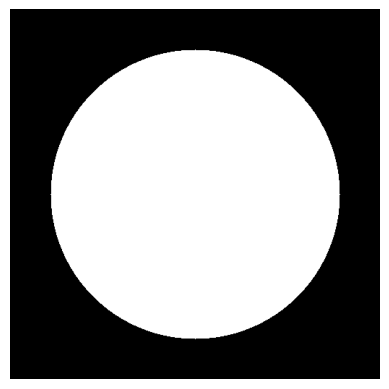

In [936]:
lens = create_lens(window, window_xcenter, window_ycenter, R_pixels)

plt.imshow(lens, cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/lens.png", dpi=300, bbox_inches='tight')

La pupila será la amplitud calculada junto con la aberración:

$P(x,y) = |P(x,y)|e^{ikW(x,y)}$.

De momento no se añaden las aberraciones,

In [937]:
def give_generalized_pupil(lens: np.ndarray, k: float, w: np.ndarray) -> np.ndarray:
  """
  Calculates genelarized pupil.

  Parameters:
    - lens (np.ndarray):
    - k (float):
    - w (np.ndarray):
  """
  factor = np.exp(1j * k * w)

  return lens * factor

In [938]:
pupil = lens.copy()

# 3. Definir $h(u,v)$

El tamaño del píxel en la imagen y la PSF será diferente: $\Delta u = \frac{\lambda z_{i}}{N \Delta x}$.

In [939]:
def calculate_new_pixel_size(wavelenght:float, z_i:float, N:int, delta_x: float) -> float:
  delta_u = (wavelenght * z_i) / (N * delta_x)

  return delta_u

delta_u = calculate_new_pixel_size(LAMBDA, z_i, N, DELTA_X)
delta_u_pixel = milimeters_to_pixel(delta_u, delta_u)

print(f"El tamaño delta_u es {delta_u:0.3f} mm, {delta_u_pixel} píxeles")

El tamaño delta_u es 0.019 mm, 1.0 píxeles


La respuesta impulso es la transformada de Fourier de la pupila $h(u,v) = \mathcal{F}\{P(x,y)\}$.

In [940]:
def get_fourier_transform(matrix: np.ndarray) -> np.ndarray:
  """
  Calculates the fourier transform and centers it.

  Parameters:
    - matrix (np.ndarray)
  """

  fourier_transform = fft2(matrix)
  shifted_fourier_transform = fftshift(fourier_transform)
  return shifted_fourier_transform

In [941]:
h = get_fourier_transform(pupil)

Se puede visualizar,

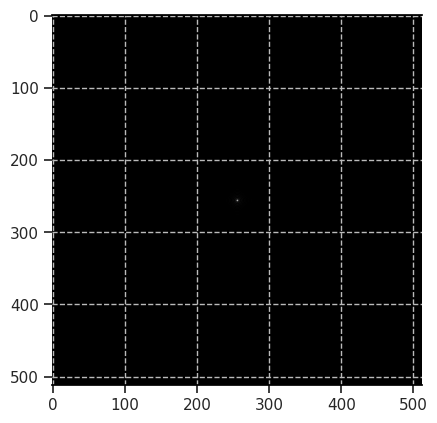

In [942]:
def complex_spectrum_visualization(matrix: np.ndarray):
    return np.abs(matrix)

spectrum_h = complex_spectrum_visualization(h)

plt.imshow(spectrum_h, cmap = "gray")
#plt.axis("off")
plt.savefig(f"{folder_name}/spectrum_h.png", dpi=300, bbox_inches='tight')

# 4. Calcular la PSF

La *point spread function* estará dada por: $PSF(u,v) = |\mathcal{F}\{{P(x,y)}\}|$,

In [943]:
psf = np.abs(h) ** 2

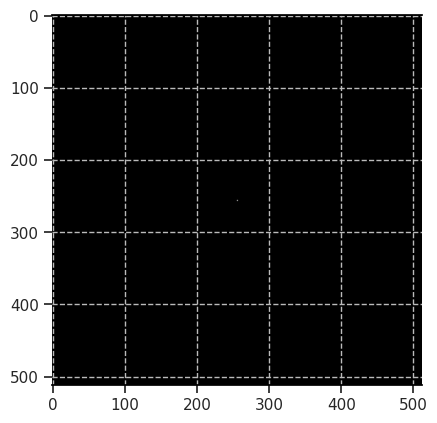

In [944]:
plt.imshow(psf, cmap = "gray")
#plt.axis("off")
plt.savefig(f"{folder_name}/PSF.png", dpi=300, bbox_inches='tight')

## 4.1. Recortar la PSF

Se añade un filtro que recorte la PSF. Para eso, se calcula el radio del disco de Airy.

In [945]:
def calculate_airy_radius(z_i: float, wavelenght: float, d: int)-> float:
  r_a = 1.22 * (wavelenght * z_i) / d
  return r_a

In [946]:
radius_airy = calculate_airy_radius(z_i, LAMBDA, D) # mm
radius_airy_px = milimeters_to_pixel(radius_airy, delta_u)

print(f"Para D = {D} mm, el radio de airy es igual a r = {radius_airy:0.2f} mm, {radius_airy_px:0.2f} píxeles")


Para D = 4 mm, el radio de airy es igual a r = 0.03 mm, 1.56 píxeles


El radio de Airy será el radio de la masca circular. Se define la función para la máscara circular,

In [947]:
def create_circle_mask(img: np.ndarray, radius: float) -> np.ndarray:
  """
  Creates a circular mask.

  Parameters:
    - img (np.darray): 2d array of the picture.
    - radius (int): wanted radius for the mask.

  Returns:
    - circle_mask (np.darray): 2d array with ones inside the
    circle and zeros everywhere else.
    - circle_coordinates (np.darray): array with the coordinates
    of the center and length of the radius.

  """
  h, w = img.shape

  center = ((w / 2), (h / 2))

  circular_mask = np.zeros_like(img)
  Y, X = np.indices((h, w))
  mask = (X - center[0]) ** 2 + (Y - center[1]) ** 2 <= (radius ** 2)
  circular_mask[mask] = 1

  circle_coordinates = np.array([center[0], center[1], radius])

  return circular_mask, circle_coordinates

Y para aplicar la máscara,

In [948]:
def crop_data(data: np.ndarray, filter:np.ndarray):
  return data * filter

Así,

In [949]:
circular_mask, circular_coordinates = create_circle_mask(psf, radius_airy_px)
cropped_psf= crop_data(psf, circular_mask)

Esto se puede visualizar,

In [950]:
def create_circle_patch(coordinates: np.ndarray):
    """
    Gives a circular patch for plotting.

    parameters:

      - coordinates (np.ndarray): a 1d array-like with four
        values [center_x, center_y, radius], defining the
        circular region in image coordinates.

    returns:
      - circle_patch (matplotlib.figure): a circular patch
        that can be plotted.

    """
    center_x, center_y, radius = coordinates

    circle_patch = patches.Circle(
      (center_x, center_y),
      radius,
      linewidth=1,
      edgecolor='white',
      facecolor='none'
    )

    return circle_patch

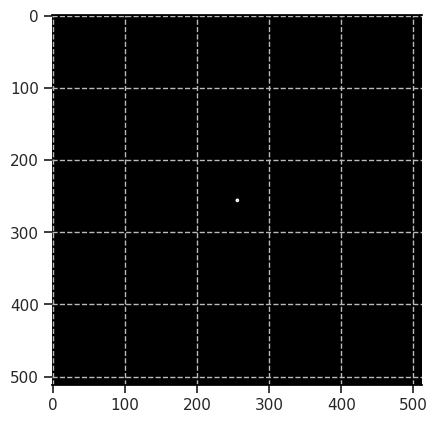

In [951]:
fig_psf, ax_psf = plt.subplots()
ax_psf.imshow(cropped_psf, cmap = "gray")
ax_psf.add_patch(create_circle_patch(circular_coordinates))

Esto se hace como visualización, no obstante, lo que se quiere es recortar solo la psf para luego hacer la visualización con esta parte.

Primero, se calcula el centroide,

In [952]:
def get_centroide_coordinates(image: np.ndarray, treshold):
    h, w = image.shape
    X, Y = np.meshgrid(np.arange(w), np.arange(h))

    mask = image > treshold
    filtered_image = image * mask

    intensity_sum = filtered_image.sum()
    x_coordinate = (X * filtered_image).sum() / intensity_sum
    y_coordinate = (Y * filtered_image).sum() / intensity_sum

    centroid_coordinates = (x_coordinate , y_coordinate)

    return centroid_coordinates

centroid_coordinates= get_centroide_coordinates(psf, 30)

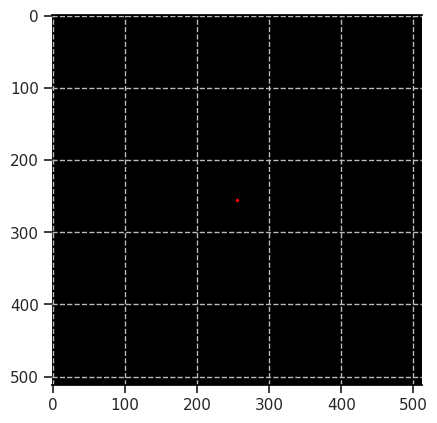

In [953]:
plt.imshow(psf, cmap='gray')
plt.scatter(centroid_coordinates[0], centroid_coordinates[1], color='red', s=2)
plt.show()

In [954]:
def extract_circle_region(img: np.ndarray, radius: float, centroid:tuple):
    """
    Gets the square region that contains the PSF.

    Parameters:
      - img (np.ndarray): psf.
      - radius (float): airy's radius.

    """

    x_min = int(centroid[0] - 2 * radius)
    x_max = int(centroid[0] + 2 * radius)
    y_min = int(centroid[1] - 2 * radius)
    y_max = int(centroid[1] + 2 * radius)

    cropped_image = img[y_min:y_max, x_min:x_max]

    return cropped_image

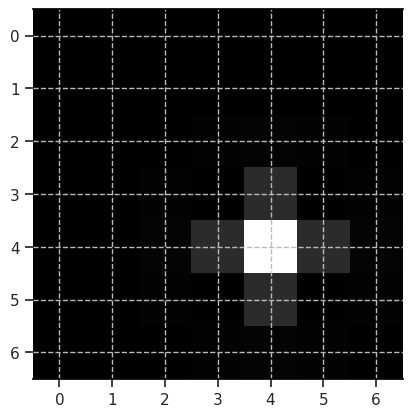

In [955]:
cropped_psf = extract_circle_region(psf, radius_airy_px, centroid_coordinates)

plt.imshow(cropped_psf, cmap = "gray")

# 5. Calcular $I_{i}(u,v)$

Se simula la imagen como: $I_{i}(u,v) = I_{g}(u,v) * PSF(u,v)$.

In [956]:
def give_image_formation(N, d, k, wavelenght, image, w, delta_x, z_i):
  """
  Simulates the formation of an image.

  Parameters:
    - N (int): window size
    - d (int): diameter size of desired lens
    - w (np.ndarray): function with desired aberration
    - delta_x (float): pixel size

  Returns:
    - image (np.ndarray): simulated image
    - h (): amplitud of the point spread func

  """
  window = np.zeros((N, N))
  window_xcenter = N // 2
  window_ycenter = N // 2

  R_pixels = milimeters_to_pixel(d, delta_x) / 2
  lens = create_lens(window, window_xcenter, window_ycenter, R_pixels)

  pupil = give_generalized_pupil(lens, k, w)
  h = get_fourier_transform(pupil)
  psf = np.abs(h) ** 2

  image = signal.fftconvolve(psf, letter_e, mode = "same")

  return image, h

In [957]:
image_test, h_test = give_image_formation(N, D, k, LAMBDA, letter_e, 0, DELTA_X, z_i)

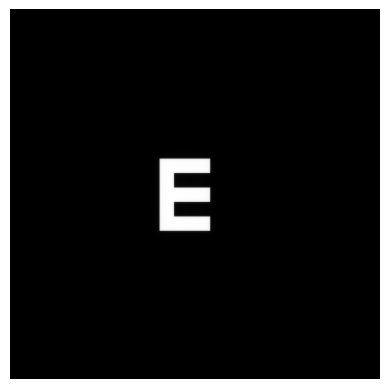

In [958]:
plt.imshow(image_test, cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/image_result.png", dpi=300, bbox_inches='tight')

# 6. Función pupila generalizada

La pupila será la amplitud calculada junto con la aberración:

$P(x,y) = |P(x,y)|e^{ikW(x,y)}$.

## 6.1. Aberración de desenfoque

El error de longitud de camino será:

$ W_{d}(x,y) = a_{d}(x^{2} + y^{2})$, con $a_{d} = \left(\frac{\Delta z}{2f^{2}}\right)$.

Se empieza por calcular $a_{d}$.

In [959]:
delta_z = np.arange(-10, 10.5, 0.5)

def get_focus_error_coefficient(delta_z: float, f: float) -> float:
  """
  Calculates the coefficient for the defocus aberration.

  Parameters:
    - delta_z (float)
    - f (float): focal distance of the lens.

  Returns:
    - focus_error_coefficient (float)

  """
  focus_error_coefficient = delta_z / (2 * (f ** 2))

  return focus_error_coefficient

Con esto, se calcula $W_{d}(x,y)$,

In [960]:
def get_defocus_aberration(delta_z: float, f: float, N: int, delta_x: float) -> np.ndarray:
  """
  Calculates the path difference of the defocus
  aberration.

  Parameters:
    - delta_z (float)
    - f (float): focal distance of the lens
    - N (int): window size
    - delta_x (float): pixel size

  Returns:
    - w_d (np.ndarray)
  """
  a_d = get_focus_error_coefficient(delta_z, f)

  h = N
  w = N
  y, x = np.indices((h, w)) * delta_x
  x = (x - w // 2)
  y = (y - h // 2)

  w_d = a_d * (x ** 2 + y ** 2)

  return w_d

Se define la expresión para la pupila generalizada,

In [961]:
def give_generalized_pupil(lens: np.ndarray, k: float, w: np.ndarray) -> np.ndarray:
  """
  Calculates genelarized pupil.

  Parameters:
    - lens (np.ndarray):
    - k (float):
    - w (np.ndarray):
  """
  factor = np.exp(1j * k * w)

  return lens * factor

Así, se calcula,

In [962]:
w_d = get_defocus_aberration(2.5, F, N, DELTA_X)

Se aplica sobre la imagen,

In [963]:
image_defocus, h_defocus = give_image_formation(N, 4, k, LAMBDA, letter_e, w_d, DELTA_X, z_i)

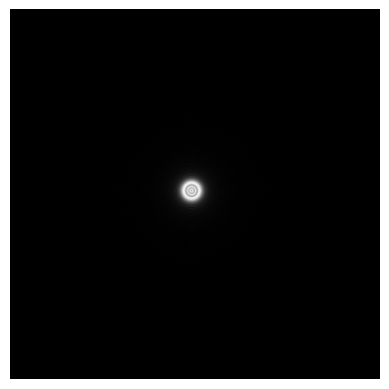

In [964]:
plt.imshow(np.abs(h_defocus), cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/psf_defocus.png", dpi=300, bbox_inches='tight')

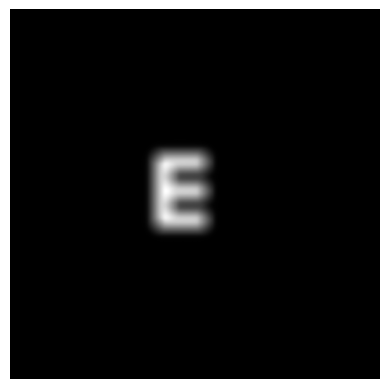

In [965]:
plt.imshow(image_defocus, cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/image_defocus.png", dpi=300, bbox_inches='tight')

## 6.2. Aberración esférica

El error de longitud de camino para la aberración esférica está dado por:

$W_{s}(x,y) = a_{s}(x^{2} + y^{2})^{2}$

El coeficiente $a_s$ debe dividirse entre $2z_{2}^{2}$.

In [966]:
A_S = 5 / (2 * (z_i ** 2))

def get_spherical_aberration(a_s, N, delta_x, f):
  x = (np.arange(N) - N / 2) * delta_x
  X, Y = np.meshgrid(x, x)

  w_s = a_s * ((X ** 2 + Y ** 2) ** 2)

  return w_s

In [967]:
w_s = get_spherical_aberration(A_S, N, DELTA_X, F)

Aplicándolo a la imagen,

In [968]:
image_spherical, h_spherical = give_image_formation(N, 4, k, LAMBDA, letter_e, w_s, DELTA_X, z_i)

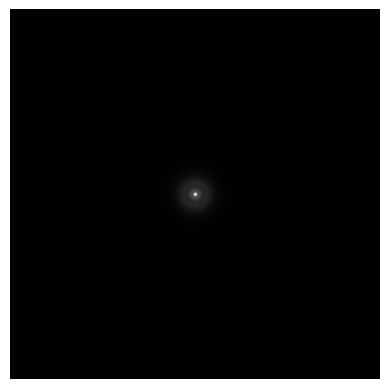

In [969]:
plt.imshow(np.abs(h_spherical), cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/psf_spherical_aberration.png", dpi=300, bbox_inches='tight')

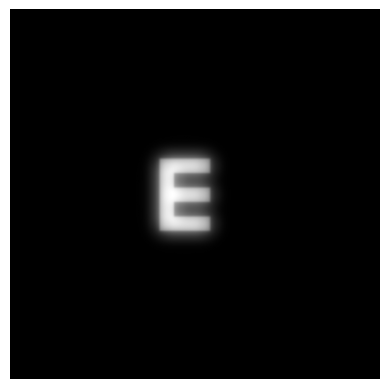

In [970]:
plt.imshow(image_spherical, cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/image_spherical_aberration.png", dpi=300, bbox_inches='tight')

## 6.3. Corrección aberración esférica

La aberración esférica se corrige añadiendo un desenfoque.

$ W(x, y) = a_{s}(x^{2} + y^{2})^{2} + a_{d} (x^{2} + y^{2})$

In [971]:
def get_correction(delta_z: float, a_s: float, f: float, N: int, delta_x: float) -> np.ndarray:
  a_d = get_focus_error_coefficient(delta_z, f)

  x = (np.arange(N) - N / 2) * delta_x
  Y, X = np.meshgrid(x, x)

  w = (a_s * ((X ** 2 + Y ** 2) ** 2)) + (a_d * (X ** 2 + Y ** 2))

  return w

In [972]:
w = get_correction(-10, A_S, F, N, DELTA_X)

image_corrected, h_corrected = give_image_formation(N, 4, k, LAMBDA, letter_e, w, DELTA_X, z_i)

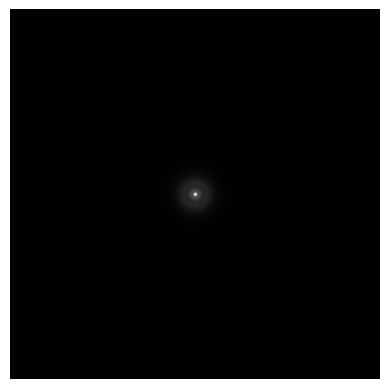

In [973]:
plt.imshow(np.abs(h_spherical), cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/h_corrected.png", dpi=300, bbox_inches='tight')

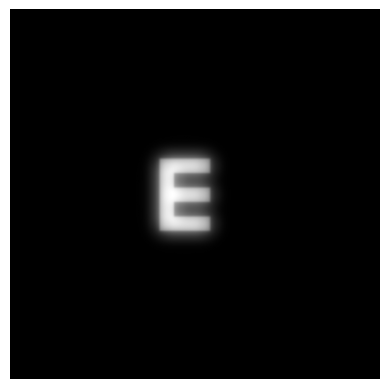

In [974]:
plt.imshow(image_spherical, cmap = "gray")
plt.axis("off")
plt.savefig(f"{folder_name}/image_corrected.png", dpi=300, bbox_inches='tight')